In [1]:
import subprocess
subprocess.run(["pip", "install", "tensorflow", "opencv-python", 
                "matplotlib", "numpy", "scikit-learn"], check=True)

CompletedProcess(args=['pip', 'install', 'tensorflow', 'opencv-python', 'matplotlib', 'numpy', 'scikit-learn'], returncode=0)

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("✅ Everything working!")

TensorFlow version: 2.21.0
✅ Everything working!


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All imports successful!")
print("TensorFlow version:", tf.__version__)

✅ All imports successful!
TensorFlow version: 2.21.0


In [4]:
# ── CHANGE ONLY THIS ──
DATASET_PATH = r"C:\Users\Tanishqa More\OneDrive\Documents\quantum_image_representation\dataset\Training"
IMG_SIZE     = 64
EPOCHS       = 20
BATCH_SIZE   = 32

print("✅ Config set!")
print("Dataset path:", DATASET_PATH)
print("Path exists:", os.path.exists(DATASET_PATH))

✅ Config set!
Dataset path: C:\Users\Tanishqa More\OneDrive\Documents\quantum_image_representation\dataset\Training
Path exists: True


In [7]:
def load_images(dataset_path, img_size):
    images, labels = [], []
    classes = {"glioma": 1, "notumor": 0}  # ← fixed folder names

    for class_name, label in classes.items():
        folder = os.path.join(dataset_path, class_name)
        if not os.path.exists(folder):
            print(f"❌ Folder not found: {folder}")
            continue

        print(f"Loading '{class_name}'...")
        count = 0
        for filename in os.listdir(folder):
            filepath = os.path.join(folder, filename)
            if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                img = cv2.imread(filepath)
                if img is None:
                    continue
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(label)
                count += 1

        print(f"  ✅ {count} images loaded for '{class_name}'")

    X = np.array(images, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32)
    return X, y

X, y_raw = load_images(DATASET_PATH, IMG_SIZE)
print(f"\nTotal images : {len(X)}")
print(f"Tumor        : {np.sum(y_raw == 1)}")
print(f"No Tumor     : {np.sum(y_raw == 0)}")

Loading 'glioma'...
  ✅ 1400 images loaded for 'glioma'
Loading 'notumor'...
  ✅ 1400 images loaded for 'notumor'

Total images : 2800
Tumor        : 1400
No Tumor     : 1400


✅ Train : 1680
✅ Val   : 560
✅ Test  : 560


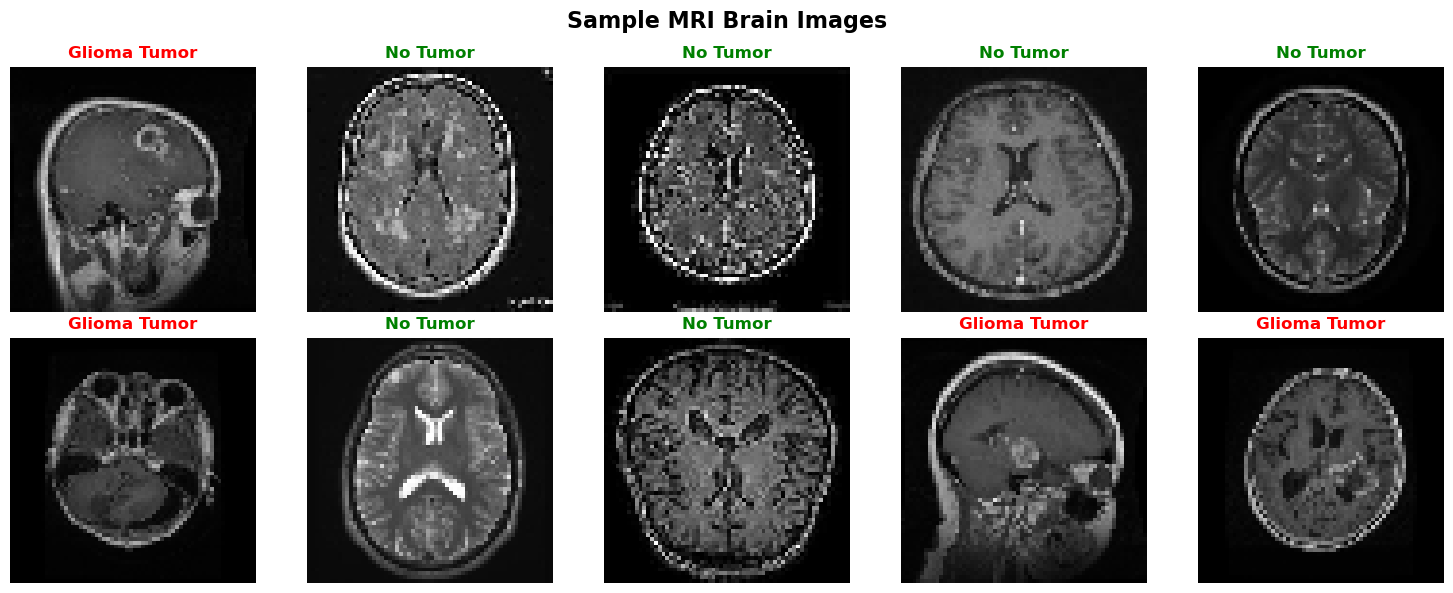

In [8]:
# Split into train, val, test
y = to_categorical(y_raw, num_classes=2)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y_raw
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"✅ Train : {len(X_train)}")
print(f"✅ Val   : {len(X_val)}")
print(f"✅ Test  : {len(X_test)}")

# Show sample images
CLASS_NAMES = ["No Tumor", "Glioma Tumor"]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
indices = np.random.choice(len(X_train), 10, replace=False)
for i, idx in enumerate(indices):
    axes[i].imshow(X_train[idx])
    axes[i].axis("off")
    label = CLASS_NAMES[np.argmax(y_train[idx])]
    color = "red" if label == "Glioma Tumor" else "green"
    axes[i].set_title(label, color=color, fontweight="bold")

plt.suptitle("Sample MRI Brain Images", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
model = Sequential([
    # Block 1 - Edge detection
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2 - Texture learning
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3 - Complex patterns
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # Classification head
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(2, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
print("\n✅ Model built successfully!")

c:\Users\Tanishqa More\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,882 (8.66 MB)

 Trainable params: 2,270,434 (8.66 MB)

 Non-trainable params: 448 (1.75 KB)


✅ Model built successfully!


In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("🚀 Training started...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
print("\n✅ Training complete!")

🚀 Training started...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.8881 - loss: 0.5151 - val_accuracy: 0.4857 - val_loss: 4.4895
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.9327 - loss: 0.2729 - val_accuracy: 0.5196 - val_loss: 0.8582
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.9530 - loss: 0.2117 - val_accuracy: 0.5143 - val_loss: 2.5244
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.9583 - loss: 0.2033 - val_accuracy: 0.5143 - val_loss: 1.2375
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.9690 - loss: 0.1216 - val_accuracy: 0.5143 - val_loss: 3.1901
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.9679 - loss: 0.0912 - val_accuracy: 0.8768 - val_loss: 0.2972
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.9786 - loss: 0.1061 - val_accuracy: 0.9250 - val_loss: 0.1912
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.9798 - loss: 0.

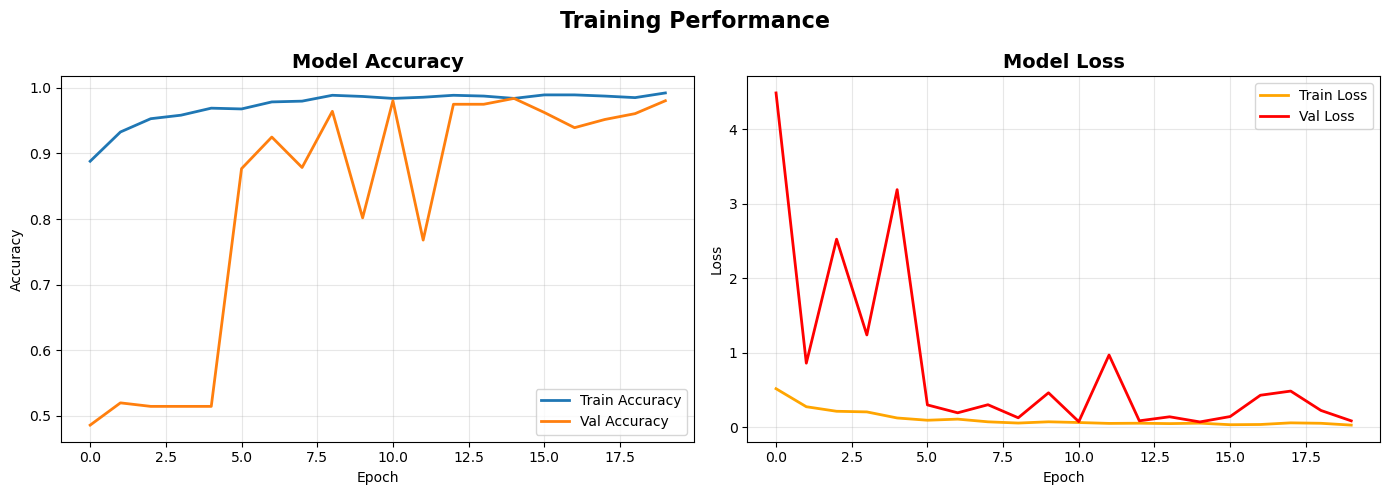

✅ Graphs plotted!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[0].set_title("Model Accuracy", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"], label="Train Loss", linewidth=2, color="orange")
axes[1].plot(history.history["val_loss"], label="Val Loss", linewidth=2, color="red")
axes[1].set_title("Model Loss", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Performance", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Graphs plotted!")

✅ Test Accuracy : 97.86%
✅ Test Loss     : 0.0540

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Tumor       1.00      0.96      0.98       272
Glioma Tumor       0.96      1.00      0.98       288

    accuracy                           0.98       560
   macro avg       0.98      0.98      0.98       560
weighted avg       0.98      0.98      0.98       560



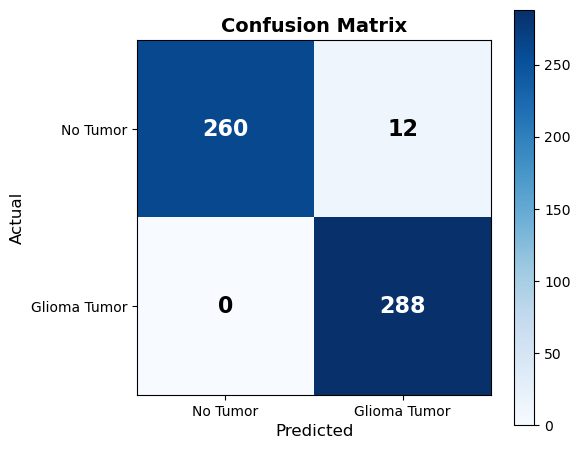

In [13]:
# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy : {test_acc * 100:.2f}%")
print(f"✅ Test Loss     : {test_loss:.4f}")

# Classification report
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n" + "="*45)
print("       CLASSIFICATION REPORT")
print("="*45)
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Glioma Tumor"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No Tumor", "Glioma Tumor"])
ax.set_yticklabels(["No Tumor", "Glioma Tumor"])
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                fontsize=16, fontweight="bold",
                color="white" if cm[i][j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

════════════════════════════════════════
  PREDICTION ON RANDOM TEST IMAGES
════════════════════════════════════════


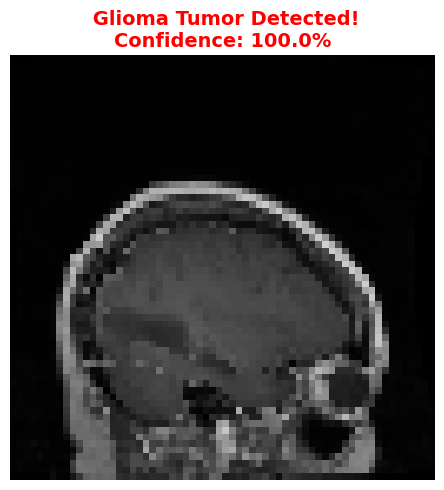

Result     :  Glioma Tumor Detected!
Confidence : 100.0%


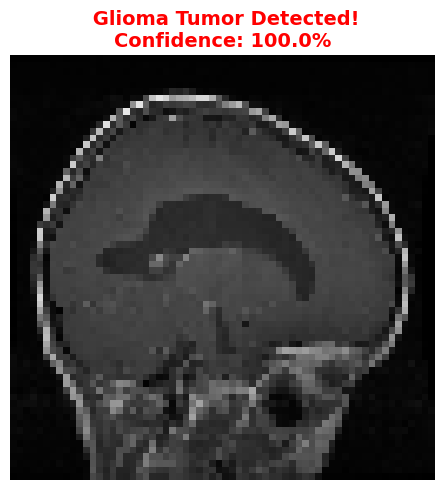

Result     :  Glioma Tumor Detected!
Confidence : 100.0%


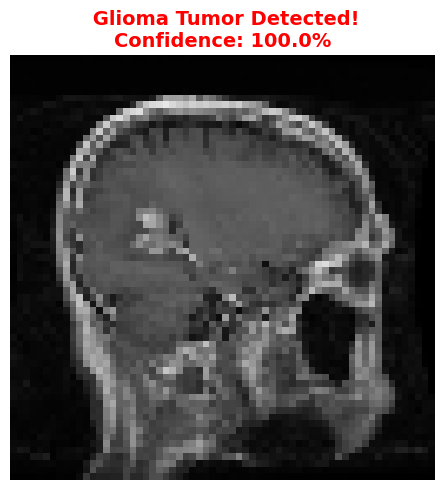

Result     :  Glioma Tumor Detected!
Confidence : 100.0%


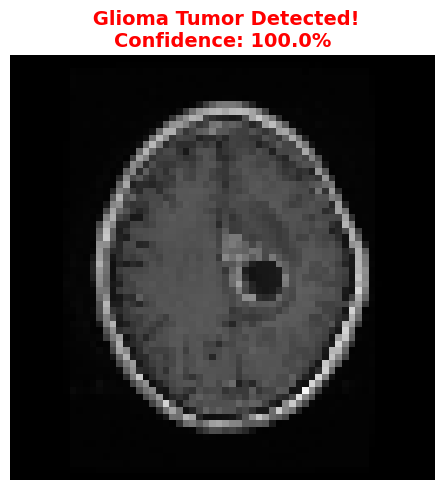

Result     :  Glioma Tumor Detected!
Confidence : 100.0%


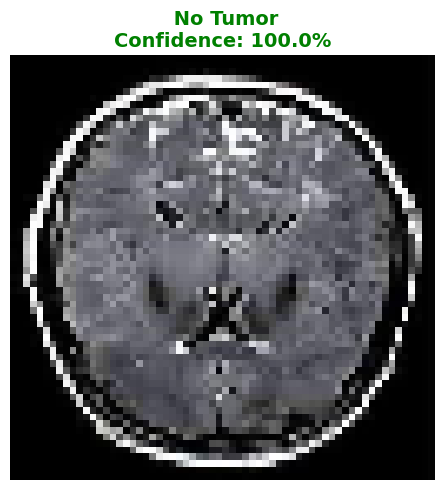

Result     :  No Tumor
Confidence : 100.0%


In [15]:
def predict_tumor(image_array):
    CLASS_NAMES = [" No Tumor", " Glioma Tumor Detected!"]
    COLORS      = ["green", "red"]

    img_display = (image_array * 255).astype(np.uint8)
    pred_probs  = model.predict(np.expand_dims(image_array, axis=0), verbose=0)[0]
    pred_class  = np.argmax(pred_probs)
    confidence  = pred_probs[pred_class] * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img_display)
    plt.axis("off")
    plt.title(
        f"{CLASS_NAMES[pred_class]}\nConfidence: {confidence:.1f}%",
        fontsize=14, fontweight="bold",
        color=COLORS[pred_class]
    )
    plt.tight_layout()
    plt.show()
    print(f"Result     : {CLASS_NAMES[pred_class]}")
    print(f"Confidence : {confidence:.1f}%")

# ── Test on random images from test set ──
print("═"*40)
print("  PREDICTION ON RANDOM TEST IMAGES")
print("═"*40)
for i in np.random.choice(len(X_test), 5, replace=False):
    predict_tumor(X_test[i])